# 08: Score-Based Discovery with GES

The earlier causal-learn lessons focused mostly on **constraint-based** discovery: PC, FCI, and CD-NOD search for graphs by asking many conditional independence questions. This lesson switches to a different family: **score-based** discovery.

Score-based discovery assigns each candidate graph a numerical score and searches for a graph that improves that score. The central algorithm here is **GES**, or Greedy Equivalence Search. GES does not test one conditional independence statement at a time. Instead, it searches over graph structures, adding and deleting edges when those operations improve a decomposable score such as BIC or BDeu.

The practical goals are:

- understand what GES is optimizing;
- run GES with a BIC-style score on continuous data;
- compare GES with PC on the same synthetic graph;
- study how penalty strength, sample size, and model mismatch affect score-based discovery;
- run a small BDeu example for discrete data;
- practice careful reporting for score-based graph search.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic graph-discovery datasets with known structural equations and known graph truth to study **Score-Based Discovery With GES**. Known graph truth lets us see when an algorithm recovers edges, misses edges, or invents edges under violated assumptions.

Read each row as a draw from a structural causal system. Columns are observed variables, and in some lessons omitted latent variables, environments, time ordering, or non-Gaussian mechanisms are deliberately introduced. The experiment studies score-based search. The score rewards fit while penalizing complexity, so the data design determines which graph is preferred.

The goal is to learn what each discovery method assumes and how its output should be audited.


## Mathematical Foundation

<!-- math-foundation-note -->

Score-based discovery searches over graphs by balancing model fit and complexity. A common score has the form

$$
\operatorname{BIC}(G)=-2\ell(\widehat\theta_G;X)+\lambda\operatorname{dim}(G)\log(n).
$$

Greedy methods move through graph space locally. Exact methods optimize more globally but become expensive as the number of variables grows. A high-scoring graph is an estimated model under a score, and its causal interpretation depends on assumptions and diagnostics.





## Tutorial Workflow

### Runtime Note

This lesson is designed to execute quickly by default, usually in about **1-3 minutes** on the current dataset and environment. It runs BIC-style GES and a small BDeu example.

causal-learn also exposes kernel/RKHS-style scores such as `local_score_CV_general` and `local_score_marginal_general`. Those can be useful for nonlinear settings, but on this 2,500-row example dataset they can take **5-15+ minutes** depending on the machine and may emit numerical warnings. For the main path, that is too much waiting, so those slower score families are discussed as optional extensions rather than executed by default.



We will work through score-based discovery in this order:

1. Set up imports, paths, GES, PC, and reusable graph helpers.
2. Load the synthetic datasets created earlier in the tutorial series.
3. Explain GES, BIC, BDeu, and the forward/backward greedy search idea.
4. Run BIC-GES on the linear Gaussian dataset.
5. Compare GES with PC on the same data.
6. Inspect GES update history, penalty sensitivity, and sample-size sensitivity.
7. Stress-test BIC-GES on non-Gaussian and nonlinear data.
8. Run BDeu-GES on the discrete example dataset.
9. Save a reporting checklist.

As in the previous lessons, every code block has explanation before it and a short discussion after it.




### GES Theory

GES, or Greedy Equivalence Search, is a score-based causal discovery algorithm. GES searches for a graph that optimizes a numerical score.

The score typically rewards goodness of fit and penalizes complexity. For continuous linear Gaussian data, BIC-style scores are common. A graph with more parents can fit the data better, but the penalty discourages adding edges that do not improve the model enough.

GES is greedy: it follows local score-improving moves. This makes it much more scalable than exact search, but it also means the path through graph space matters.





## Diagnostics and Interpretation

### Decomposable Scores

GES works efficiently because many graph scores are decomposable. A decomposable score can be written as a sum of local node scores:

$$
S(G) = \sum_i S_i(\mathrm{Pa}(X_i))
$$

This means the contribution for `X_i` depends only on the parent set of `X_i`. If a proposed move changes only the parents of one node, the algorithm can update only that local score and avoid refitting the entire graph from scratch.

Decomposability is one reason score-based discovery can be practical. It is also why parent-set assumptions and score choice matter so much.




### BIC and Complexity Penalties

BIC balances model fit against model complexity. In causal discovery, adding an edge usually adds a parameter because the child variable gets another parent. More parameters can improve fit, but they can also overfit sample noise.

A BIC-style score therefore asks: does the improvement in likelihood justify the extra complexity? If yes, the edge may be added. If no, the penalty wins and the simpler graph is preferred.

The penalty strength is a substantive modeling choice. Stronger penalties produce sparser graphs; weaker penalties allow denser graphs. This is why the GES lesson includes penalty sensitivity.


### Equivalence Classes And Single DAGs

GES searches over Markov equivalence classes because observational scores cannot uniquely identify every DAG orientation. Multiple DAGs can imply the same conditional independence structure and receive equivalent scores under common assumptions.

The output is often represented as a CPDAG-like graph. Directed edges are compelled across the equivalence class; undirected edges are not uniquely oriented by the score and assumptions.

This is conceptually similar to PC's CPDAG output. Both methods can leave edges unoriented when observational information does not compel a direction.


#### Forward and Backward Phases

GES usually has two main phases.

The **forward phase** starts from an empty graph and greedily adds edges or edge patterns that improve the score. This phase increases model complexity when the fit improvement is worthwhile.

The **backward phase** starts from the forward result and greedily deletes edges when removal improves the score. This phase corrects some over-addition from the forward phase and searches for a better sparse explanation.

Some implementations also include turning or refinement steps. The key idea remains the same: local moves are accepted when they improve the score.




### Score Assumptions and Model Mismatch

A score encodes assumptions. A linear Gaussian BIC score is most appropriate when the data are reasonably modeled by linear relationships with Gaussian residuals. If the true mechanisms are nonlinear, discrete, heavy-tailed, or heteroskedastic, the score may prefer a graph that is statistically convenient and still causally fragile.

This is why a score-based workflow should include mechanism checks and alternative scores when appropriate. For discrete data, a BDeu-style score may be more natural than a continuous BIC score.

The graph should be interpreted as the best explanation under the chosen score, penalty, and search procedure, with causal interpretation handled through assumptions and diagnostics.




### What GES Can and Cannot Claim

GES can efficiently search large graph spaces and often performs well when its score assumptions match the data. It is useful as a complement to PC because it approaches discovery through model fit and gives another view of the candidate structure.

GES cannot guarantee a global optimum. It is greedy, so local decisions can affect the final graph. It also cannot identify directions that are not identifiable under the observational equivalence class without additional assumptions.

A good GES report documents the score, penalty, data type, search settings, sample-size sensitivity, and any comparison to constraint-based or exact-search results.


#### Setup

This setup block imports the scientific stack, GES, PC, and plotting utilities. It also applies a small local compatibility wrapper for causal-learn's BIC score in this Python/NumPy environment. The wrapper fixes scalar extraction from a one-element matrix and does **not** edit the installed package on disk.


In [1]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import contextlib
import io
import os
import warnings
# Keep matplotlib cache writes inside the repository so notebook execution works in restricted environments.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import causallearn.search.ScoreBased.GES as ges_module
from causallearn.search.ScoreBased.GES import ges
from causallearn.search.ConstraintBased.PC import pc
# Resolve paths whether the notebook is run from the repository root or from this lesson folder.
CWD = Path.cwd()
if CWD.name == "causal_learn" and (CWD / "outputs").exists():
    NOTEBOOK_DIR = CWD
else:
    NOTEBOOK_DIR = (CWD / "notebooks" / "tutorials" / "causal_learn").resolve()
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
for directory in [OUTPUT_DIR, DATASET_DIR, TABLE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
NOTEBOOK_PREFIX = "08"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.facecolor"] = "white"
def local_score_BIC_from_cov(Data, i, PAi, parameters=None):
    """
    Compatibility wrapper for causal-learn BIC score under recent NumPy scalar behavior.
    
    Parameters
    ----------
    Data : array-like
        Data matrix passed by causal-learn into the local score function.
    i : int
        Target variable index for the local score calculation.
    PAi : list[int]
        Parent indices proposed for the target variable in the local score.
    parameters : dict
        Score-function parameters supplied by causal-learn.
    
    Returns
    -------
    float
        BIC-style local score for one target variable and candidate parent set.
    """
    cov, n = Data
    lambda_value = 0.5 if parameters is None else parameters.get("lambda_value", 0.5)
    sigma = float(cov[i, i])
    if len(PAi) > 0:
        yX = cov[np.ix_([i], PAi)]
        XX = cov[np.ix_(PAi, PAi)]
        try:
            XX_inv = np.linalg.inv(XX)
        except np.linalg.LinAlgError:
            XX_inv = np.linalg.pinv(XX)
        sigma = float(cov[i, i] - (yX @ XX_inv @ yX.T).item())
    sigma = max(sigma, 1e-12)
    return -0.5 * n * (1 + np.log(sigma)) - lambda_value * (len(PAi) + 1) * np.log(n)
# Patch only the imported module object used during this lesson session.
ges_module.local_score_BIC_from_cov = local_score_BIC_from_cov
packages = ["causal-learn", "numpy", "pandas", "matplotlib", "seaborn"]
version_rows = []
for package in packages:
    try:
        package_version = version(package)
    except PackageNotFoundError:
        package_version = "not installed"
    version_rows.append({"package": package, "version": package_version})
package_versions = pd.DataFrame(version_rows)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)


,package,version
0,causal-learn,0.1.4.5
1,numpy,2.4.4
2,pandas,3.0.2
3,matplotlib,3.10.9
4,seaborn,0.13.2


The version table and compatibility wrapper make the lesson reproducible in this environment. The wrapper preserves the same BIC formula; it only converts a one-element NumPy result into a Python scalar before scoring.


#### Load Example Datasets

We use four datasets from the synthetic data factory:

- `02_linear_gaussian.csv`: the best match for BIC-GES because the score assumes linear Gaussian local regressions;
- `02_linear_nongaussian.csv`: same broad graph family but with non-Gaussian noise;
- `02_nonlinear_continuous.csv`: a deliberate mismatch for linear Gaussian BIC;
- `02_discrete_mixed.csv`: a small discrete example for BDeu-GES.

The true edge tables are loaded only for tutorial evaluation. Real causal discovery work would not know the true graph.


In [2]:
# Load datasets and true edge lists created by tutorial notebook 02.
dataset_paths = {
    "linear_gaussian": DATASET_DIR / "02_linear_gaussian.csv",
    "linear_nongaussian": DATASET_DIR / "02_linear_nongaussian.csv",
    "nonlinear_continuous": DATASET_DIR / "02_nonlinear_continuous.csv",
    "discrete_mixed": DATASET_DIR / "02_discrete_mixed.csv",
}
true_edge_path = TABLE_DIR / "02_base_true_dag_edges.csv"
discrete_true_edge_path = TABLE_DIR / "02_discrete_mixed_true_edges.csv"
required_paths = list(dataset_paths.values()) + [true_edge_path, discrete_true_edge_path]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Run tutorial notebook 02 first. Missing files: " + ", ".join(missing_paths))
datasets = {name: pd.read_csv(path) for name, path in dataset_paths.items()}
true_edges = pd.read_csv(true_edge_path)
discrete_true_edges = pd.read_csv(discrete_true_edge_path)
VARIABLES = list(datasets["linear_gaussian"].columns)
loaded_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": len(df),
            "columns": df.shape[1],
            "missing_cells": int(df.isna().sum().sum()),
            "source_file": dataset_paths[name].name,
        }
        for name, df in datasets.items()
    ]
)
loaded_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_loaded_dataset_summary.csv", index=False)
display(loaded_summary)
display(datasets["linear_gaussian"].head())
display(true_edges)


,dataset,rows,columns,missing_cells,source_file
0,linear_gaussian,2500,6,0,02_linear_gaussian.csv
1,linear_nongaussian,2500,6,0,02_linear_nongaussian.csv
2,nonlinear_continuous,2500,6,0,02_nonlinear_continuous.csv
3,discrete_mixed,2500,6,0,02_discrete_mixed.csv


,need,intent,match,engagement,renewal,support
0,0.249820,-0.372094,0.060245,0.667197,0.252766,-0.280058
1,0.683671,-0.210471,0.904969,1.004727,0.320095,-0.332215
2,-0.579752,-1.202671,-0.578579,-0.235444,-0.732431,0.594102
3,-0.902823,-0.077309,-0.771219,-0.531128,-0.105721,-1.503551
4,-1.985745,0.087297,-0.691315,-1.281731,-0.797906,-0.328219


,source,target,edge_type,mechanism
0,need,match,directed,Need changes what a good match means.
1,intent,match,directed,Current intent changes recommendation relevance.
2,match,engagement,directed,Better matching increases engagement depth.
3,intent,renewal,directed,Intent directly affects later value.
4,engagement,renewal,directed,Engagement contributes to renewal value.
5,engagement,support,directed,Engagement creates more chances for support contact.


All datasets use the same six observed variables, which makes graph comparisons straightforward. The first run will use `linear_gaussian` because BIC-GES is best aligned with that data-generating setup.


### GES Concept Map

GES searches over equivalence classes of DAGs using score improvements. It usually has two major stages: a forward stage that greedily inserts edges to improve the score, and a backward stage that deletes edges if doing so improves the score.

The output should be read as a candidate equivalence-class graph. Some directions may be compelled, while other adjacencies may remain unoriented because several DAGs can have the same score under the assumptions.


| concept | plain_language | why_it_matters |
| --- | --- | --- |
| score-based discovery | Search for a graph that optimizes a numerical fit-plus-penalty score. | The result depends on score assumptions and search choices, more than independence tests. |
| GES forward phase | Greedily insert edges or operators that improve the graph score. | Early additions can shape the graph neighborhood explored later. |
| GES backward phase | Delete edges or operators when deletion improves the score. | The backward phase can simplify an overly dense forward graph. |
| BIC score | Fit a linear Gaussian local model and penalize parent-set complexity. | Good match for linear Gaussian data; weaker match for nonlinear mechanisms. |
| BDeu score | Score discrete Bayesian-network structures with Dirichlet priors. | Useful for categorical data when states and priors are documented. |


The concept map sets up the rest of the lesson. The key shift from PC is that we are now asking whether a graph scores well under a modeling assumption, not whether a specific conditional independence test rejects or fails to reject.


#### Helper Functions

This helper block defines graph conversion, metric, update-history, and plotting utilities. The graph helpers are similar to earlier lessons so the visual language stays consistent across the tutorial series.


In [3]:
# Define reusable helpers for the Helper Functions section.
def parse_causallearn_edge(edge):
    """
    Convert a causal-learn edge object into source, endpoint pattern, and target strings.
    
    Parameters
    ----------
    edge : object
        Graph edge object or edge row being parsed, classified, or drawn.
    
    Returns
    -------
    tuple[str, str, str]
        Source node, endpoint mark, and target node parsed from a causal-learn edge.
    """
    parts = str(edge).strip().split()
    if len(parts) != 3:
        return {"source": str(edge), "edge_type": "unknown", "target": "unknown"}
    return {"source": parts[0], "edge_type": parts[1], "target": parts[2]}
def graph_to_edge_table(graph, label):
    """
    Return a tidy edge table from a causal-learn graph object.
    
    Parameters
    ----------
    graph : object
        Graph object returned by causal-learn or constructed from the edge table.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    pd.DataFrame
        Edge table with source, target, edge mark, and method metadata.
    """
    rows = [parse_causallearn_edge(edge) for edge in graph.get_graph_edges()]
    edge_df = pd.DataFrame(rows, columns=["source", "edge_type", "target"])
    if edge_df.empty:
        edge_df = pd.DataFrame(columns=["source", "edge_type", "target"])
    edge_df.insert(0, "run", label)
    return edge_df
def directed_pairs(edge_df):
    """
    Extract definite directed pairs from an edge table.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    
    Returns
    -------
    set[tuple[str, str]]
        Ordered source-target pairs representing directed learned edges.
    """
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.edge_type == "-->":
            pairs.add((row.source, row.target))
        elif row.edge_type == "<--":
            pairs.add((row.target, row.source))
    return pairs
def skeleton_pairs(edge_df):
    """
    Extract learned adjacencies while ignoring endpoint direction.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    
    Returns
    -------
    set[tuple[str, str]]
        Unordered node pairs representing the learned graph skeleton.
    """
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.target != "unknown":
            pairs.add(frozenset([row.source, row.target]))
    return pairs
def summarize_against_truth(edge_df, truth_df, label):
    """
    Compute compact graph-recovery metrics against the synthetic truth table.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    truth_df : pd.DataFrame
        Oracle edge table used as the synthetic ground-truth benchmark.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    pd.DataFrame
        Graph-recovery summary table with edge counts, precision, recall, missing edges, and extra edges.
    """
    true_directed = set(zip(truth_df["source"], truth_df["target"]))
    true_skeleton = {frozenset(edge) for edge in true_directed}
    learned_directed = directed_pairs(edge_df)
    learned_skeleton = skeleton_pairs(edge_df)
    correct_directed = learned_directed & true_directed
    reversed_true = {(src, dst) for src, dst in true_directed if (dst, src) in learned_directed}
    missing_skeleton = true_skeleton - learned_skeleton
    extra_skeleton = learned_skeleton - true_skeleton
    unresolved_true = 0
    for src, dst in true_directed:
        pair = frozenset([src, dst])
        if pair in learned_skeleton and (src, dst) not in learned_directed and (dst, src) not in learned_directed:
            unresolved_true += 1
    directed_count = len(learned_directed)
    return pd.DataFrame(
        [
            {
                "run": label,
                "learned_edges_total": len(edge_df),
                "definite_directed_edges": directed_count,
                "true_edges": len(true_directed),
                "correct_directed_edges": len(correct_directed),
                "directed_precision": len(correct_directed) / directed_count if directed_count else np.nan,
                "directed_recall": len(correct_directed) / len(true_directed) if true_directed else np.nan,
                "reversed_true_edges": len(reversed_true),
                "unresolved_true_adjacencies": unresolved_true,
                "missing_true_adjacencies": len(missing_skeleton),
                "extra_adjacencies": len(extra_skeleton),
            }
        ]
    )
def classify_edges(edge_df, truth_df):
    """
    Label learned edges relative to the synthetic truth table.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    truth_df : pd.DataFrame
        Oracle edge table used as the synthetic ground-truth benchmark.
    
    Returns
    -------
    pd.DataFrame
        Graph edge table for classify edges, including node names and edge-orientation information where available.
    """
    true_directed = set(zip(truth_df["source"], truth_df["target"]))
    true_skeleton = {frozenset(edge) for edge in true_directed}
    rows = []
    for row in edge_df.itertuples(index=False):
        pair = frozenset([row.source, row.target])
        learned_direction = None
        if row.edge_type == "-->":
            learned_direction = (row.source, row.target)
        elif row.edge_type == "<--":
            learned_direction = (row.target, row.source)
        if learned_direction in true_directed:
            status = "correct directed edge"
        elif learned_direction and (learned_direction[1], learned_direction[0]) in true_directed:
            status = "reversed true edge"
        elif pair in true_skeleton:
            status = "true adjacency with uncertain or wrong endpoint"
        else:
            status = "extra adjacency"
        rows.append({"source": row.source, "edge_type": row.edge_type, "target": row.target, "status": status})
    return pd.DataFrame(rows)
def run_ges_bic(data_df, label, lambda_value=0.5, maxP=None):
    """
    Run BIC-GES quietly and return the record plus tidy edge table.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Dataset for the current simulated or observed experiment.
    label : str
        Readable label attached to the method, scenario, or output row.
    lambda_value : float
        Numeric value for `lambda`.
    maxP : object
        Maximum number of parents allowed by the GES search call.
    
    Returns
    -------
    tuple
        Tuple containing record, edge_table, messages.
    """
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        record = ges(
            data_df.to_numpy(),
            score_func="local_score_BIC",
            node_names=list(data_df.columns),
            lambda_value=lambda_value,
            maxP=maxP,
        )
    edge_table = graph_to_edge_table(record["G"], label=label)
    messages = pd.DataFrame({"run": label, "message": [line for line in buffer.getvalue().splitlines() if line.strip()]})
    return record, edge_table, messages
def run_pc_baseline(data_df, label):
    """
    Run Fisher-Z PC as a constraint-based baseline.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Dataset for the current simulated or observed experiment.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    pd.DataFrame
        Baseline PC edge table recovered from the selected dataset.
    """
    result = pc(
        data_df.to_numpy(),
        alpha=0.05,
        indep_test="fisherz",
        stable=True,
        show_progress=False,
        node_names=list(data_df.columns),
    )
    return graph_to_edge_table(result.G, label=label)
def operation_table(record, variable_names):
    """
    Summarize GES forward and backward updates using variable names.
    
    Parameters
    ----------
    record : object
        Single benchmark record being converted into a table row.
    variable_names : object
        Variable names used to label graph nodes or matrix columns.
    
    Returns
    -------
    pd.DataFrame
        Table describing how GES search operations add, delete, or reverse edges.
    """
    rows = []
    for phase, updates in [("forward_insert", record.get("update1", [])), ("backward_delete", record.get("update2", []))]:
        for step, update in enumerate(updates, start=1):
            source_idx, target_idx, conditioning_set = update
            rows.append(
                {
                    "phase": phase,
                    "step": step,
                    "source_index": int(source_idx),
                    "target_index": int(target_idx),
                    "source_variable": variable_names[int(source_idx)],
                    "target_variable": variable_names[int(target_idx)],
                    "conditioning_set": [variable_names[int(idx)] for idx in conditioning_set],
                }
            )
    return pd.DataFrame(rows)
GRAPH_POSITIONS = {
    "need": (0.11, 0.72),
    "intent": (0.11, 0.28),
    "match": (0.39, 0.50),
    "engagement": (0.62, 0.50),
    "renewal": (0.89, 0.72),
    "support": (0.89, 0.28),
}
NODE_LABELS = {name: name.title() for name in GRAPH_POSITIONS}
NODE_COLORS = {
    "need": "#e0f2fe",
    "intent": "#dbeafe",
    "match": "#ecfccb",
    "engagement": "#fef3c7",
    "renewal": "#fee2e2",
    "support": "#f3e8ff",
}
def trim_edge_to_box(start, end, box_w=0.145, box_h=0.095, gap=0.012):
    """
    Return edge endpoints that stop just outside source and target boxes.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate of the arrow or edge segment.
    end : tuple[float, float]
        Ending coordinate of the arrow or edge segment.
    box_w : float
        Width of the node box used to trim edge endpoints.
    box_h : float
        Height of the node box used to trim edge endpoints.
    gap : float
        Extra spacing between an edge endpoint and a node boundary.
    
    Returns
    -------
    tuple[tuple[float, float], tuple[float, float]]
        Start and end coordinates trimmed so the edge stops at box boundaries.
    """
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    length = float(np.hypot(dx, dy))
    if length == 0:
        return start, end
    effective_w = box_w + 0.04
    effective_h = box_h + 0.04
    x_limit = (effective_w / 2) / abs(dx) if dx else np.inf
    y_limit = (effective_h / 2) / abs(dy) if dy else np.inf
    t = min(x_limit, y_limit) + gap / length
    return (x0 + dx * t, y0 + dy * t), (x1 - dx * t, y1 - dy * t)
def draw_box_graph(edge_df, title, path, note=None):
    """
    Draw a DAG/CPDAG-style graph with rounded boxes and visible arrowheads.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    title : str
        Title shown above the plot.
    path : str or pathlib.Path
        Optional output path for the figure.
    note : str or None
        Optional explanatory note shown in the plot.
    
    Returns
    -------
    None
        Draws the graph diagram directly on the Matplotlib axes and saves it when requested.
    """
    fig, ax = plt.subplots(figsize=(12, 6.2))
    ax.set_axis_off()
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0.04, 0.96)
    box_w, box_h = 0.145, 0.095
    for row in edge_df.itertuples(index=False):
        if row.source not in GRAPH_POSITIONS or row.target not in GRAPH_POSITIONS:
            continue
        raw_start = GRAPH_POSITIONS[row.source]
        raw_end = GRAPH_POSITIONS[row.target]
        if row.edge_type == "<--":
            raw_start, raw_end = raw_end, raw_start
        start, end = trim_edge_to_box(raw_start, raw_end, box_w=box_w, box_h=box_h)
        if row.edge_type in {"-->", "<--"}:
            arrowstyle = "-|>"
            mutation_scale = 18
            linewidth = 1.8
            color = "#334155"
        else:
            arrowstyle = "-"
            mutation_scale = 1
            linewidth = 1.5
            color = "#64748b"
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle=arrowstyle,
            mutation_scale=mutation_scale,
            linewidth=linewidth,
            color=color,
            connectionstyle="arc3,rad=0.035",
            zorder=2,
        )
        ax.add_patch(arrow)
    for node, (x, y) in GRAPH_POSITIONS.items():
        rect = FancyBboxPatch(
            (x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.018",
            facecolor=NODE_COLORS[node],
            edgecolor="#1f2937",
            linewidth=1.1,
            zorder=5,
        )
        ax.add_patch(rect)
        ax.text(x, y, NODE_LABELS[node], ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=6)
    if note:
        ax.text(0.50, 0.08, note, ha="center", va="center", fontsize=10, color="#475569")
    ax.set_title(title, pad=18, fontsize=14, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
def truth_as_edge_table(truth_df, label="truth"):
    """
    Convert a truth edge table to the plotting schema.
    
    Parameters
    ----------
    truth_df : pd.DataFrame
        Oracle edge table used as the synthetic ground-truth benchmark.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    pd.DataFrame
        Oracle graph edge table with run label and directed-edge marks.
    """
    return truth_df.assign(run=label, edge_type="-->")[["run", "source", "edge_type", "target"]]


The helpers let us compare GES, PC, BIC penalties, sample sizes, and data-generating regimes using the same edge-table and graph-metric vocabulary.


#### Draw the Reference Graph

The reference graph is the synthetic data-generating structure. It is included for learning evaluation, not because real causal discovery work would know the answer in advance.


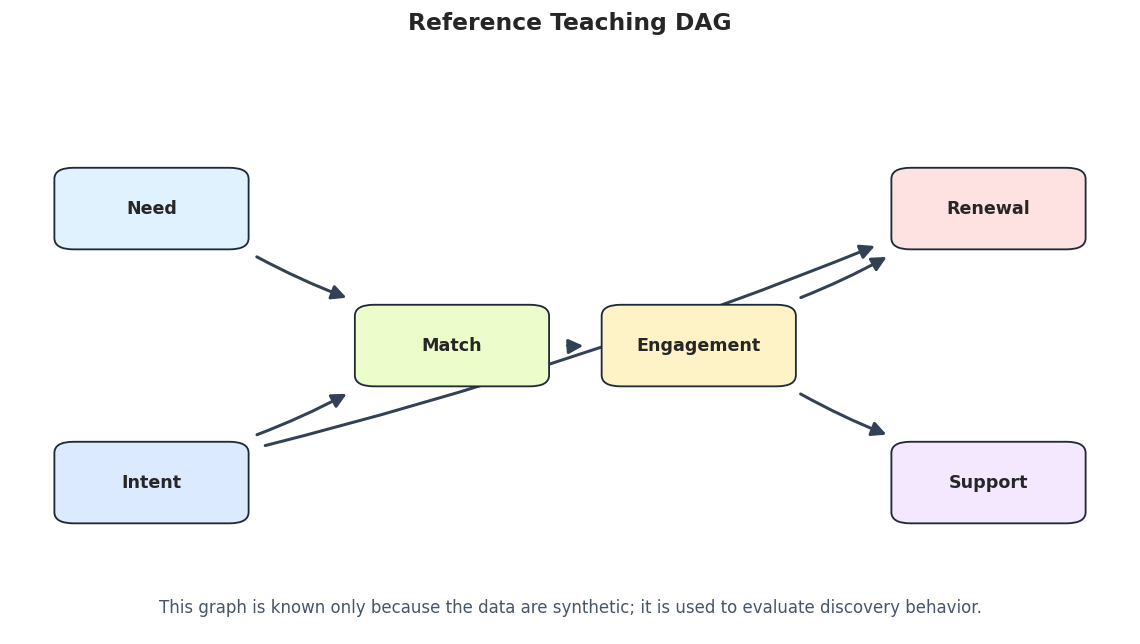

In [4]:
# Draw the reference example graph.
true_edge_table = truth_as_edge_table(true_edges, label="true_graph")
true_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_dag.png"
draw_box_graph(
    true_edge_table,
    title="Reference Teaching DAG",
    path=true_graph_path,
    note="This graph is known only because the data are synthetic; it is used to evaluate discovery behavior.",
)


The reference graph gives us a visual target for the score-based runs. BIC-GES should perform best on the linear Gaussian dataset because that is the closest match to the score assumptions.




#### Continuous Data Audit

Before running a linear Gaussian score, we audit the linear Gaussian dataset. The BIC score uses covariance and local linear regressions, so the correlation structure is especially relevant.


In [5]:
# Summarize the continuous baseline data and save its correlation matrix.
linear_df = datasets["linear_gaussian"]
linear_audit = pd.DataFrame(
    {
        "variable": VARIABLES,
        "missing_rate": linear_df.isna().mean().reindex(VARIABLES).to_numpy(),
        "mean": linear_df.mean().reindex(VARIABLES).to_numpy(),
        "std": linear_df.std().reindex(VARIABLES).to_numpy(),
        "min": linear_df.min().reindex(VARIABLES).to_numpy(),
        "max": linear_df.max().reindex(VARIABLES).to_numpy(),
    }
)
linear_corr = linear_df.corr()
linear_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_linear_gaussian_data_audit.csv", index=False)
linear_corr.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_linear_gaussian_correlation_matrix.csv")
display(linear_audit)
display(linear_corr.round(3))


,variable,missing_rate,mean,std,min,max
0,need,0.0,3.552714e-18,1.0002,-3.371900,3.316358
1,intent,0.0,-9.947598e-18,1.0002,-3.467962,3.389982
2,match,0.0,-3.552714e-19,1.0002,-3.596272,3.917631
3,engagement,0.0,-1.776357e-18,1.0002,-3.404627,3.469112
4,renewal,0.0,-8.526513e-18,1.0002,-3.418065,3.122549
5,support,0.0,1.563194e-17,1.0002,-3.250120,3.174916


,need,intent,match,engagement,renewal,support
need,1.000,0.007,0.595,0.494,0.211,0.311
intent,0.007,1.000,0.638,0.529,0.735,0.307
match,0.595,0.638,1.000,0.821,0.665,0.489
engagement,0.494,0.529,0.821,1.000,0.670,0.582
renewal,0.211,0.735,0.665,0.670,1.000,0.384
support,0.311,0.307,0.489,0.582,0.384,1.000


The data are complete and centered enough for a clean tutorial example. The correlation matrix shows dependence structure, while GES uses a graph score to build candidate edges.


#### Plot the Correlation Matrix

The heatmap gives a visual sense of the dependence structure that the score-based search will try to explain through parent sets.


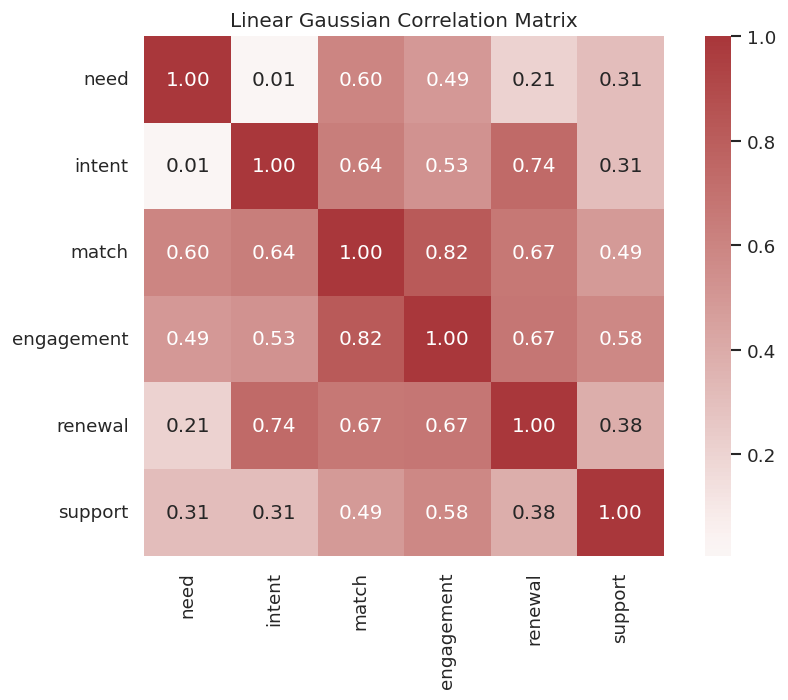

In [6]:
# Plot the baseline correlation matrix.
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(linear_corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Linear Gaussian Correlation Matrix")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_linear_gaussian_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


The heatmap is only a diagnostic. The next step runs GES and asks which graph scores best under the local linear Gaussian BIC objective.




#### Baseline BIC-GES on Linear Gaussian Data

This is the main GES run. We use the standard BIC penalty coefficient `lambda_value=0.5`, which corresponds to the usual BIC-style complexity penalty in causal-learn's implementation.


In [7]:
# Run BIC-GES on the linear Gaussian dataset.
ges_record, ges_edges, ges_messages = run_ges_bic(
    linear_df,
    label="bic_ges_linear_gaussian",
    lambda_value=0.5,
)
ges_metrics = summarize_against_truth(ges_edges, true_edges, "bic_ges_linear_gaussian")
ges_classified = classify_edges(ges_edges, true_edges)
baseline_score_summary = pd.DataFrame(
    [
        {
            "run": "bic_ges_linear_gaussian",
            "score": ges_record["score"],
            "forward_updates": len(ges_record.get("update1", [])),
            "backward_updates": len(ges_record.get("update2", [])),
            "lambda_value": 0.5,
        }
    ]
)
baseline_score_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_ges_score_summary.csv", index=False)
ges_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_ges_edges.csv", index=False)
ges_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_ges_metrics.csv", index=False)
ges_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_ges_edge_classification.csv", index=False)
ges_messages.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_ges_messages.csv", index=False)
display(baseline_score_summary)
display(ges_edges)
display(ges_metrics)
display(ges_classified)


,run,score,forward_updates,backward_updates,lambda_value
0,bic_ges_linear_gaussian,-2547.995676,8,2,0.5


,run,source,edge_type,target
0,bic_ges_linear_gaussian,need,-->,match
1,bic_ges_linear_gaussian,intent,-->,match
2,bic_ges_linear_gaussian,intent,-->,renewal
3,bic_ges_linear_gaussian,match,-->,engagement
4,bic_ges_linear_gaussian,engagement,-->,renewal
5,bic_ges_linear_gaussian,engagement,-->,support


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,bic_ges_linear_gaussian,6,6,6,6,1.0,1.0,0,0,0,0


,source,edge_type,target,status
0,need,-->,match,correct directed edge
1,intent,-->,match,correct directed edge
2,intent,-->,renewal,correct directed edge
3,match,-->,engagement,correct directed edge
4,engagement,-->,renewal,correct directed edge
5,engagement,-->,support,correct directed edge


On the linear Gaussian example data, BIC-GES recovers the intended graph cleanly. This is the friendly case: the data-generating assumptions line up well with the score.


#### Draw the Baseline GES Graph

The graph below is the baseline score-based discovery result. It should look familiar from the PC lesson because this synthetic dataset is easy for both Fisher-Z PC and BIC-GES by construction.


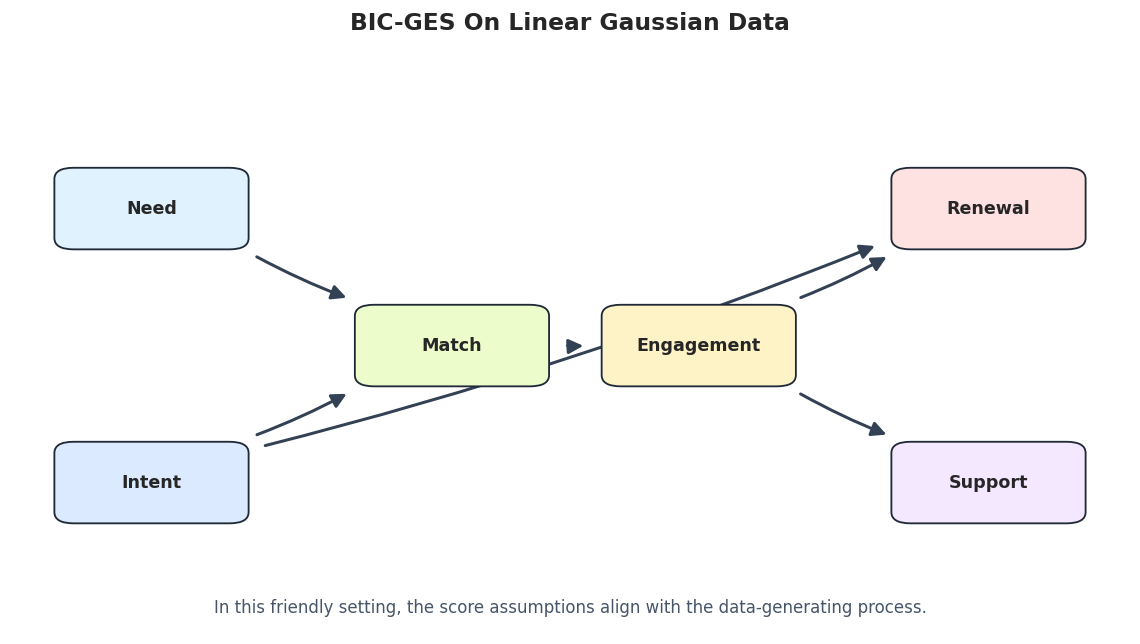

In [8]:
# Draw and save the baseline GES graph.
baseline_ges_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_baseline_ges_graph.png"
draw_box_graph(
    ges_edges,
    title="BIC-GES On Linear Gaussian Data",
    path=baseline_ges_graph_path,
    note="In this friendly setting, the score assumptions align with the data-generating process.",
)


The graph is clean because the example is well matched to BIC-GES. The next section opens the search record so students can see that GES reached this graph through forward and backward operations.


#### GES Update History

GES is greedy: it records forward insert operations and backward delete operations. The raw update objects are index-based, so this step maps them back to variable names.


In [9]:
# Summarize the forward and backward GES update history.
ges_updates = operation_table(ges_record, VARIABLES)
ges_updates.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_ges_update_history.csv", index=False)
display(ges_updates)


,phase,step,source_index,target_index,source_variable,target_variable,conditioning_set
0,forward_insert,1,2,3,match,engagement,[]
1,forward_insert,2,4,1,renewal,intent,[]
2,forward_insert,3,4,3,renewal,engagement,[]
3,forward_insert,4,2,0,match,need,[]
4,forward_insert,5,1,0,intent,need,[match]
5,forward_insert,6,3,5,engagement,support,[]
6,forward_insert,7,1,2,intent,match,[engagement]
7,forward_insert,8,1,3,intent,engagement,[]
8,backward_delete,1,0,1,need,intent,[match]
9,backward_delete,2,1,3,intent,engagement,[]


The update table shows the search path and the final graph. This is useful when debugging a score-based result because two final graphs can have similar scores but different search trajectories.




#### Compare GES with PC

Now we run PC on the same linear Gaussian dataset. This is not a contest to crown one method permanently better. It is a controlled comparison between constraint-based and score-based discovery under friendly assumptions.


In [10]:
# Run PC on the same linear Gaussian data and compare with GES.
pc_edges = run_pc_baseline(linear_df, label="pc_fisherz_linear_gaussian")
pc_metrics = summarize_against_truth(pc_edges, true_edges, "pc_fisherz_linear_gaussian")
pc_classified = classify_edges(pc_edges, true_edges)
pc_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_baseline_edges.csv", index=False)
pc_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_baseline_metrics.csv", index=False)
pc_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_baseline_edge_classification.csv", index=False)
method_comparison = pd.concat([ges_metrics, pc_metrics], ignore_index=True)
method_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_ges_vs_pc_metrics.csv", index=False)
display(pc_edges)
display(method_comparison)


,run,source,edge_type,target
0,pc_fisherz_linear_gaussian,need,-->,match
1,pc_fisherz_linear_gaussian,intent,-->,match
2,pc_fisherz_linear_gaussian,intent,-->,renewal
3,pc_fisherz_linear_gaussian,match,-->,engagement
4,pc_fisherz_linear_gaussian,engagement,-->,renewal
5,pc_fisherz_linear_gaussian,engagement,-->,support


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,bic_ges_linear_gaussian,6,6,6,6,1.0,1.0,0,0,0,0
1,pc_fisherz_linear_gaussian,6,6,6,6,1.0,1.0,0,0,0,0


In this controlled case, both methods recover the graph well. That agreement is useful: when methods with different search logic agree under plausible assumptions, the candidate structure is easier to trust.


#### Plot GES versus PC Metrics

A compact plot makes the method comparison easier to scan. We focus on correct directed edges, reversed true edges, unresolved true adjacencies, and extra adjacencies.


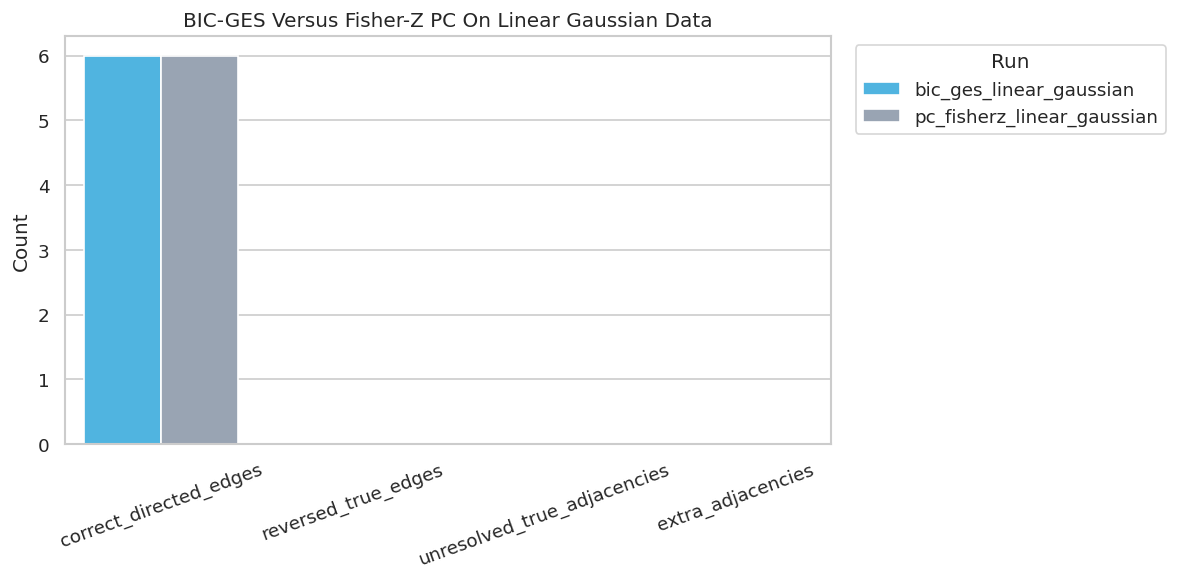

In [11]:
# Plot GES and PC metric comparison.
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = method_comparison.melt(
    id_vars="run",
    value_vars=["correct_directed_edges", "reversed_true_edges", "unresolved_true_adjacencies", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)
sns.barplot(data=plot_df, x="metric", y="count", hue="run", ax=ax, palette=["#38bdf8", "#94a3b8"])
ax.set_title("BIC-GES Versus Fisher-Z PC On Linear Gaussian Data")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_ges_vs_pc_metrics.png", dpi=160, bbox_inches="tight")
plt.show()


The plot reinforces the friendly-case message. The next sections make the lesson more realistic by changing penalty strength, sample size, and data-generating assumptions.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->


#### BIC Penalty Sensitivity

The BIC penalty controls how much complexity is punished. A lower penalty can allow denser graphs; a higher penalty can prefer simpler graphs. The code below runs BIC-GES across several `lambda_value` choices.


In [12]:
# Run BIC-GES across penalty strengths.
lambda_values = [0.25, 0.5, 1.0, 2.0]
lambda_metric_rows = []
lambda_edge_rows = []
lambda_score_rows = []
for lambda_value in lambda_values:
    label = f"bic_ges_lambda_{lambda_value:g}"
    record, edge_table, messages = run_ges_bic(linear_df, label=label, lambda_value=lambda_value)
    metrics = summarize_against_truth(edge_table, true_edges, label).assign(lambda_value=lambda_value)
    lambda_metric_rows.append(metrics)
    lambda_edge_rows.append(edge_table.assign(lambda_value=lambda_value))
    lambda_score_rows.append(
        {
            "run": label,
            "lambda_value": lambda_value,
            "score": record["score"],
            "forward_updates": len(record.get("update1", [])),
            "backward_updates": len(record.get("update2", [])),
        }
    )
lambda_metrics = pd.concat(lambda_metric_rows, ignore_index=True)
lambda_edges = pd.concat(lambda_edge_rows, ignore_index=True)
lambda_scores = pd.DataFrame(lambda_score_rows)
lambda_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bic_lambda_sensitivity_metrics.csv", index=False)
lambda_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bic_lambda_sensitivity_edges.csv", index=False)
lambda_scores.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bic_lambda_sensitivity_scores.csv", index=False)
display(lambda_scores)
display(lambda_metrics)
display(lambda_edges)


,run,lambda_value,score,forward_updates,backward_updates
0,bic_ges_lambda_0.25,0.25,-2524.523538,8,2
1,bic_ges_lambda_0.5,0.50,-2547.995676,8,2
2,bic_ges_lambda_1,1.00,-2608.870598,7,0
3,bic_ges_lambda_2,2.00,-2710.583196,7,0


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies,lambda_value
0,bic_ges_lambda_0.25,6,6,6,6,1.00,1.000000,0,0,0,0,0.25
1,bic_ges_lambda_0.5,6,6,6,6,1.00,1.000000,0,0,0,0,0.50
2,bic_ges_lambda_1,7,4,6,1,0.25,0.166667,2,3,0,1,1.00
3,bic_ges_lambda_2,7,4,6,1,0.25,0.166667,2,3,0,1,2.00


,run,source,edge_type,target,lambda_value
0,bic_ges_lambda_0.25,need,-->,match,0.25
1,bic_ges_lambda_0.25,intent,-->,match,0.25
2,bic_ges_lambda_0.25,intent,-->,renewal,0.25
3,bic_ges_lambda_0.25,match,-->,engagement,0.25
4,bic_ges_lambda_0.25,engagement,-->,renewal,0.25
5,bic_ges_lambda_0.25,engagement,-->,support,0.25
6,bic_ges_lambda_0.5,need,-->,match,0.50
7,bic_ges_lambda_0.5,intent,-->,match,0.50
8,bic_ges_lambda_0.5,intent,-->,renewal,0.50
9,bic_ges_lambda_0.5,match,-->,engagement,0.50


The penalty sensitivity table shows that the standard penalty works well here, while stronger penalties can change the discovered structure. This is why score-based results should report tuning choices alongside the graph and its assumptions.


#### Plot Penalty Sensitivity

The plot tracks graph quality metrics across BIC penalty strengths. It helps students see when a score penalty starts changing the graph materially.


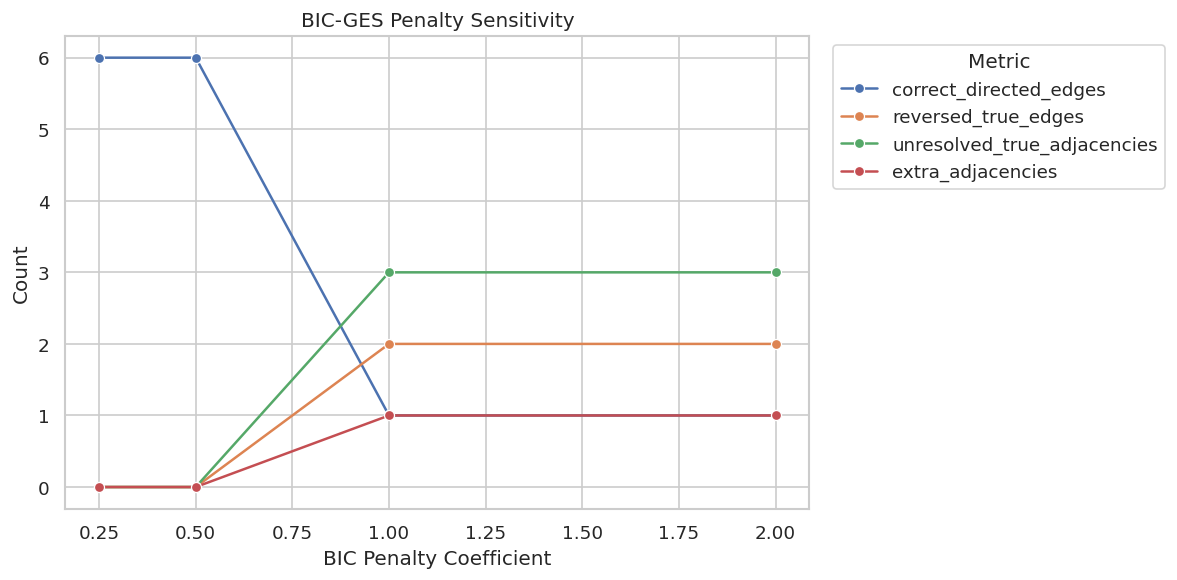

In [13]:
# Plot BIC penalty sensitivity.
fig, ax = plt.subplots(figsize=(10, 5))
lambda_plot = lambda_metrics.melt(
    id_vars=["run", "lambda_value"],
    value_vars=["correct_directed_edges", "reversed_true_edges", "unresolved_true_adjacencies", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)
sns.lineplot(data=lambda_plot, x="lambda_value", y="count", hue="metric", marker="o", ax=ax)
ax.set_title("BIC-GES Penalty Sensitivity")
ax.set_xlabel("BIC Penalty Coefficient")
ax.set_ylabel("Count")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_bic_lambda_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


The sensitivity curve makes tuning visible. If a graph only appears for one penalty value, the report should treat it as less stable than a graph that persists across nearby choices.


#### Sample-Size Sensitivity

Score-based search can be unstable with small samples because local score differences are harder to estimate. The code below reruns BIC-GES on subsamples of increasing size.


In [14]:
# Run BIC-GES on increasing sample sizes.
sample_sizes = [100, 250, 500, 1000, len(linear_df)]
sample_metric_rows = []
sample_edge_rows = []
sample_score_rows = []
for sample_size in sample_sizes:
    sample_df = linear_df.sample(n=sample_size, random_state=908 + sample_size)
    label = f"bic_ges_n_{sample_size}"
    record, edge_table, messages = run_ges_bic(sample_df, label=label, lambda_value=0.5)
    metrics = summarize_against_truth(edge_table, true_edges, label).assign(sample_size=sample_size)
    sample_metric_rows.append(metrics)
    sample_edge_rows.append(edge_table.assign(sample_size=sample_size))
    sample_score_rows.append(
        {
            "run": label,
            "sample_size": sample_size,
            "score": record["score"],
            "forward_updates": len(record.get("update1", [])),
            "backward_updates": len(record.get("update2", [])),
        }
    )
sample_metrics = pd.concat(sample_metric_rows, ignore_index=True)
sample_edges = pd.concat(sample_edge_rows, ignore_index=True)
sample_scores = pd.DataFrame(sample_score_rows)
sample_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity_metrics.csv", index=False)
sample_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity_edges.csv", index=False)
sample_scores.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity_scores.csv", index=False)
display(sample_scores)
display(sample_metrics)
display(sample_edges.head(20))


,run,sample_size,score,forward_updates,backward_updates
0,bic_ges_n_100,100,-79.144994,7,0
1,bic_ges_n_250,250,-245.731976,8,2
2,bic_ges_n_500,500,-511.203702,8,2
3,bic_ges_n_1000,1000,-962.730373,8,2
4,bic_ges_n_2500,2500,-2547.995676,8,2


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies,sample_size
0,bic_ges_n_100,7,2,6,2,1.0,0.333333,0,4,0,1,100
1,bic_ges_n_250,6,6,6,6,1.0,1.000000,0,0,0,0,250
2,bic_ges_n_500,6,6,6,6,1.0,1.000000,0,0,0,0,500
3,bic_ges_n_1000,6,6,6,6,1.0,1.000000,0,0,0,0,1000
4,bic_ges_n_2500,6,6,6,6,1.0,1.000000,0,0,0,0,2500


,run,source,edge_type,target,sample_size
0,bic_ges_n_100,need,---,intent,100
1,bic_ges_n_100,need,---,match,100
2,bic_ges_n_100,intent,---,match,100
3,bic_ges_n_100,intent,-->,renewal,100
4,bic_ges_n_100,match,---,engagement,100
5,bic_ges_n_100,engagement,-->,renewal,100
6,bic_ges_n_100,engagement,---,support,100
7,bic_ges_n_250,need,-->,match,250
8,bic_ges_n_250,intent,-->,match,250
9,bic_ges_n_250,intent,-->,renewal,250


Small samples can leave edges unoriented or add extra adjacencies. By a few hundred rows in this synthetic setup, BIC-GES becomes much more stable, which is exactly the kind of sample-size story a good report should include.


#### Plot Sample-Size Sensitivity

This plot makes the sample-size pattern easier to read. It tracks correct directed edges, unresolved true adjacencies, and extra adjacencies as the available data grow.


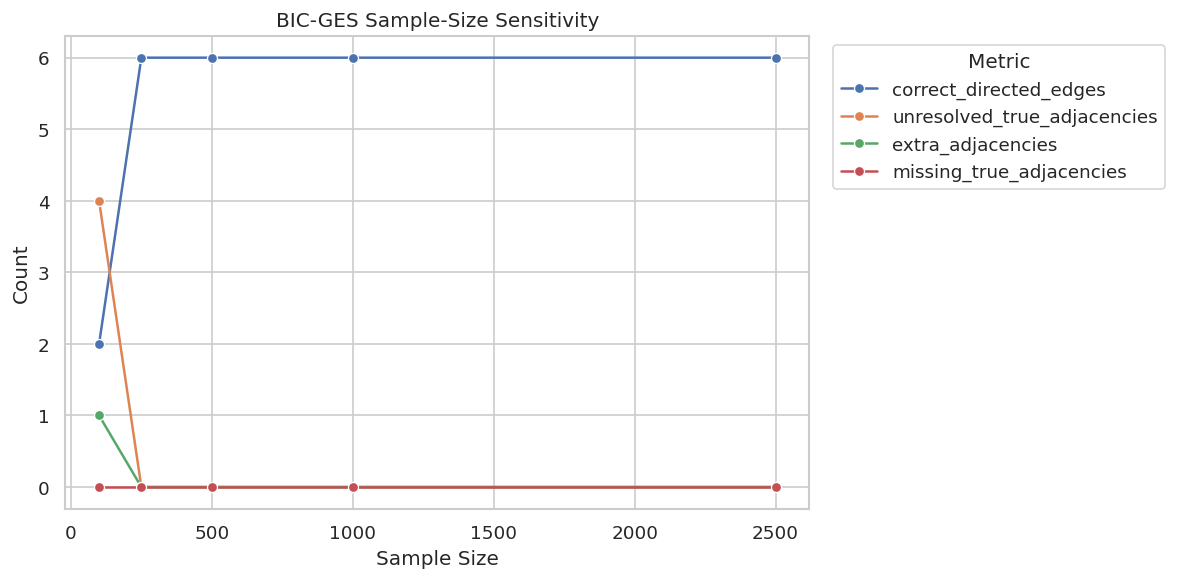

In [15]:
# Plot sample-size sensitivity for BIC-GES.
fig, ax = plt.subplots(figsize=(10, 5))
sample_plot = sample_metrics.melt(
    id_vars=["run", "sample_size"],
    value_vars=["correct_directed_edges", "unresolved_true_adjacencies", "extra_adjacencies", "missing_true_adjacencies"],
    var_name="metric",
    value_name="count",
)
sns.lineplot(data=sample_plot, x="sample_size", y="count", hue="metric", marker="o", ax=ax)
ax.set_title("BIC-GES Sample-Size Sensitivity")
ax.set_xlabel("Sample Size")
ax.set_ylabel("Count")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


The sample-size plot is a useful diagnostic for any score-based discovery workflow. Stable graph recovery at larger samples is more reassuring than a graph that only appears in one small subsample.


#### Model-Mismatch Stress Test

BIC-GES is a linear Gaussian score. This section runs the same method on three datasets with different mechanisms. The purpose is to show that score assumptions matter.


In [16]:
# Run BIC-GES on datasets with increasingly mismatched mechanisms.
regime_metric_rows = []
regime_edge_rows = []
regime_score_rows = []
for dataset_name in ["linear_gaussian", "linear_nongaussian", "nonlinear_continuous"]:
    label = f"bic_ges_{dataset_name}"
    record, edge_table, messages = run_ges_bic(datasets[dataset_name], label=label, lambda_value=0.5)
    metrics = summarize_against_truth(edge_table, true_edges, label).assign(dataset=dataset_name)
    regime_metric_rows.append(metrics)
    regime_edge_rows.append(edge_table.assign(dataset=dataset_name))
    regime_score_rows.append(
        {
            "run": label,
            "dataset": dataset_name,
            "score": record["score"],
            "forward_updates": len(record.get("update1", [])),
            "backward_updates": len(record.get("update2", [])),
        }
    )
regime_metrics = pd.concat(regime_metric_rows, ignore_index=True)
regime_edges = pd.concat(regime_edge_rows, ignore_index=True)
regime_scores = pd.DataFrame(regime_score_rows)
regime_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_mechanism_stress_test_metrics.csv", index=False)
regime_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_mechanism_stress_test_edges.csv", index=False)
regime_scores.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_mechanism_stress_test_scores.csv", index=False)
display(regime_scores)
display(regime_metrics)
display(regime_edges)


,run,dataset,score,forward_updates,backward_updates
0,bic_ges_linear_gaussian,linear_gaussian,-2547.995676,8,2
1,bic_ges_linear_nongaussian,linear_nongaussian,-2561.286088,8,1
2,bic_ges_nonlinear_continuous,nonlinear_continuous,-4253.218605,9,0


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies,dataset
0,bic_ges_linear_gaussian,6,6,6,6,1.000000,1.000000,0,0,0,0,linear_gaussian
1,bic_ges_linear_nongaussian,7,7,6,6,0.857143,1.000000,0,0,0,1,linear_nongaussian
2,bic_ges_nonlinear_continuous,9,6,6,1,0.166667,0.166667,2,3,0,3,nonlinear_continuous


,run,source,edge_type,target,dataset
0,bic_ges_linear_gaussian,need,-->,match,linear_gaussian
1,bic_ges_linear_gaussian,intent,-->,match,linear_gaussian
2,bic_ges_linear_gaussian,intent,-->,renewal,linear_gaussian
3,bic_ges_linear_gaussian,match,-->,engagement,linear_gaussian
4,bic_ges_linear_gaussian,engagement,-->,renewal,linear_gaussian
5,bic_ges_linear_gaussian,engagement,-->,support,linear_gaussian
6,bic_ges_linear_nongaussian,need,-->,match,linear_nongaussian
7,bic_ges_linear_nongaussian,intent,-->,match,linear_nongaussian
8,bic_ges_linear_nongaussian,intent,-->,engagement,linear_nongaussian
9,bic_ges_linear_nongaussian,intent,-->,renewal,linear_nongaussian


The stress test shows the main limitation of a score: when the score is mismatched to the data-generating process, the discovered graph can deteriorate. The nonlinear dataset is especially hard for a linear Gaussian score.




#### Plot Model-Mismatch Results

The plot compares graph recovery across the three mechanism regimes. It is a quick way to see where BIC-GES is reliable and where its assumptions start to fray.


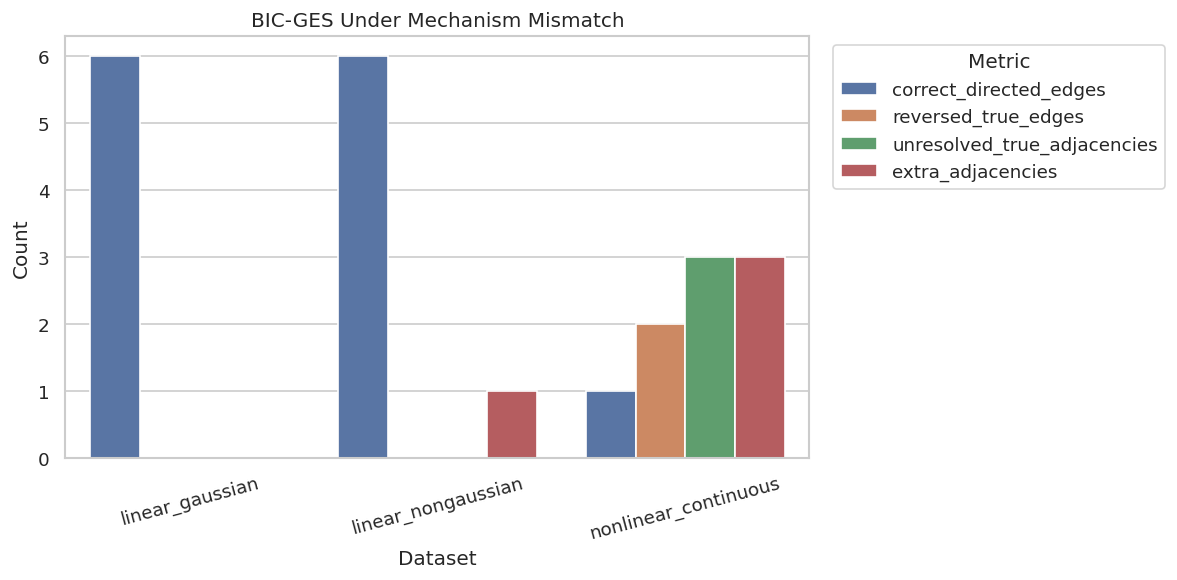

In [17]:
# Plot the mechanism mismatch stress test.
fig, ax = plt.subplots(figsize=(10, 5))
regime_plot = regime_metrics.melt(
    id_vars=["run", "dataset"],
    value_vars=["correct_directed_edges", "reversed_true_edges", "unresolved_true_adjacencies", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)
sns.barplot(data=regime_plot, x="dataset", y="count", hue="metric", ax=ax)
ax.set_title("BIC-GES Under Mechanism Mismatch")
ax.set_xlabel("Dataset")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_mechanism_stress_test.png", dpi=160, bbox_inches="tight")
plt.show()


The plot is the cautionary center of the lesson. Score-based discovery is only as credible as the score family and the data representation that support it.




#### Draw the Nonlinear Stress-Test Graph

The nonlinear graph is worth drawing because it shows what model mismatch looks like visually: extra arrows, reversed directions, and less faithful structure.


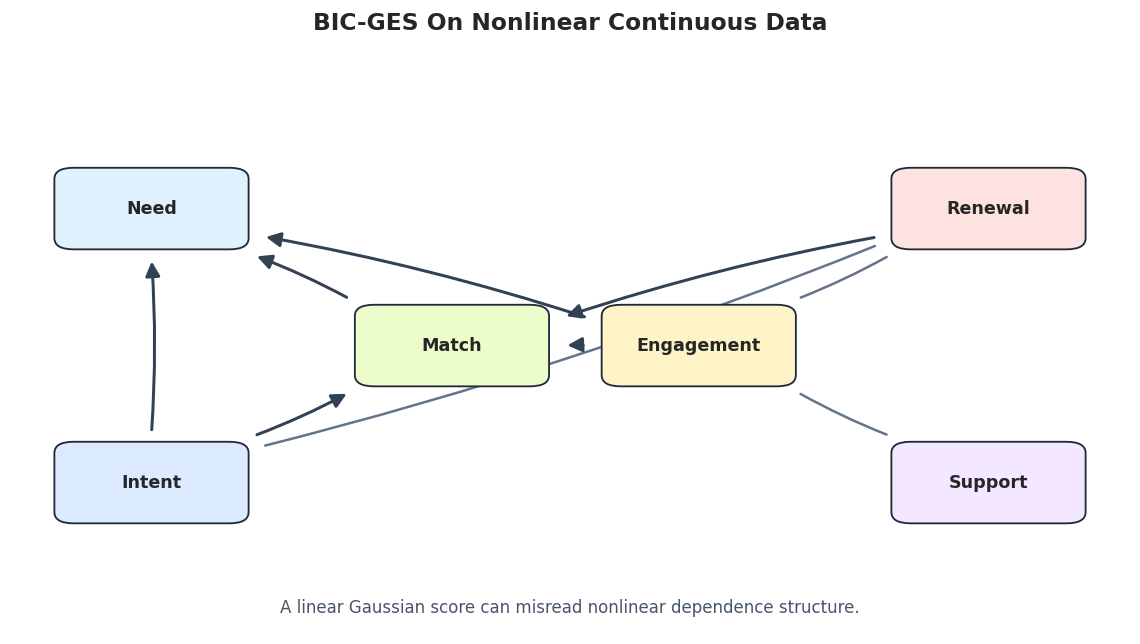

In [18]:
# Draw the BIC-GES result on nonlinear continuous data.
nonlinear_edges = regime_edges[regime_edges["dataset"] == "nonlinear_continuous"].drop(columns=["dataset"])
nonlinear_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_nonlinear_bic_ges_graph.png"
draw_box_graph(
    nonlinear_edges,
    title="BIC-GES On Nonlinear Continuous Data",
    path=nonlinear_graph_path,
    note="A linear Gaussian score can misread nonlinear dependence structure.",
)


The nonlinear graph is less trustworthy than the baseline graph. This is where a report should consider nonlinear scores, transformations, or an additional discovery method to support BIC-GES.


#### Discrete Score Example: BDeu-GES

BIC is not the only score. For discrete data, causal-learn supports BDeu-style scoring. This section runs GES on the discrete example dataset to show how the score family changes with data type.


In [19]:
# Run BDeu-GES on the discrete dataset.
discrete_df = datasets["discrete_mixed"].astype(int)
r_i_map = {i: int(discrete_df.iloc[:, i].nunique()) for i in range(discrete_df.shape[1])}
bdeu_parameters = {"sample_prior": 1, "structure_prior": 1, "r_i_map": r_i_map}
buffer = io.StringIO()
with contextlib.redirect_stdout(buffer):
    bdeu_record = ges(
        discrete_df.to_numpy(),
        score_func="local_score_BDeu",
        node_names=list(discrete_df.columns),
        parameters=bdeu_parameters,
    )
bdeu_edges = graph_to_edge_table(bdeu_record["G"], label="bdeu_ges_discrete_mixed")
bdeu_metrics = summarize_against_truth(bdeu_edges, discrete_true_edges, "bdeu_ges_discrete_mixed")
bdeu_classified = classify_edges(bdeu_edges, discrete_true_edges)
bdeu_score_summary = pd.DataFrame(
    [
        {
            "run": "bdeu_ges_discrete_mixed",
            "score": bdeu_record["score"],
            "forward_updates": len(bdeu_record.get("update1", [])),
            "backward_updates": len(bdeu_record.get("update2", [])),
            "sample_prior": bdeu_parameters["sample_prior"],
            "structure_prior": bdeu_parameters["structure_prior"],
        }
    ]
)
bdeu_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bdeu_ges_edges.csv", index=False)
bdeu_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bdeu_ges_metrics.csv", index=False)
bdeu_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bdeu_ges_edge_classification.csv", index=False)
bdeu_score_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bdeu_ges_score_summary.csv", index=False)
display(bdeu_score_summary)
display(bdeu_edges)
display(bdeu_metrics)
display(bdeu_classified)


,run,score,forward_updates,backward_updates,sample_prior,structure_prior
0,bdeu_ges_discrete_mixed,-10499.860061,6,0,1,1


,run,source,edge_type,target
0,bdeu_ges_discrete_mixed,need,---,match
1,bdeu_ges_discrete_mixed,match,-->,intent
2,bdeu_ges_discrete_mixed,renewal,-->,intent
3,bdeu_ges_discrete_mixed,match,---,engagement
4,bdeu_ges_discrete_mixed,engagement,---,renewal
5,bdeu_ges_discrete_mixed,engagement,---,support


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,bdeu_ges_discrete_mixed,6,2,6,0,0.0,0.0,2,4,0,0


,source,edge_type,target,status
0,need,---,match,true adjacency with uncertain or wrong endpoint
1,match,-->,intent,reversed true edge
2,renewal,-->,intent,reversed true edge
3,match,---,engagement,true adjacency with uncertain or wrong endpoint
4,engagement,---,renewal,true adjacency with uncertain or wrong endpoint
5,engagement,---,support,true adjacency with uncertain or wrong endpoint


The BDeu example is more modest than the BIC baseline. It shows how to switch score families for discrete data, while also showing that discretization and prior choices can make orientation recovery harder.




#### Draw the BDeu-GES Graph

The discrete graph is drawn with the same layout so it can be compared against the continuous BIC-GES graph. Undirected edges are shown as plain lines because GES can leave equivalence-class uncertainty.


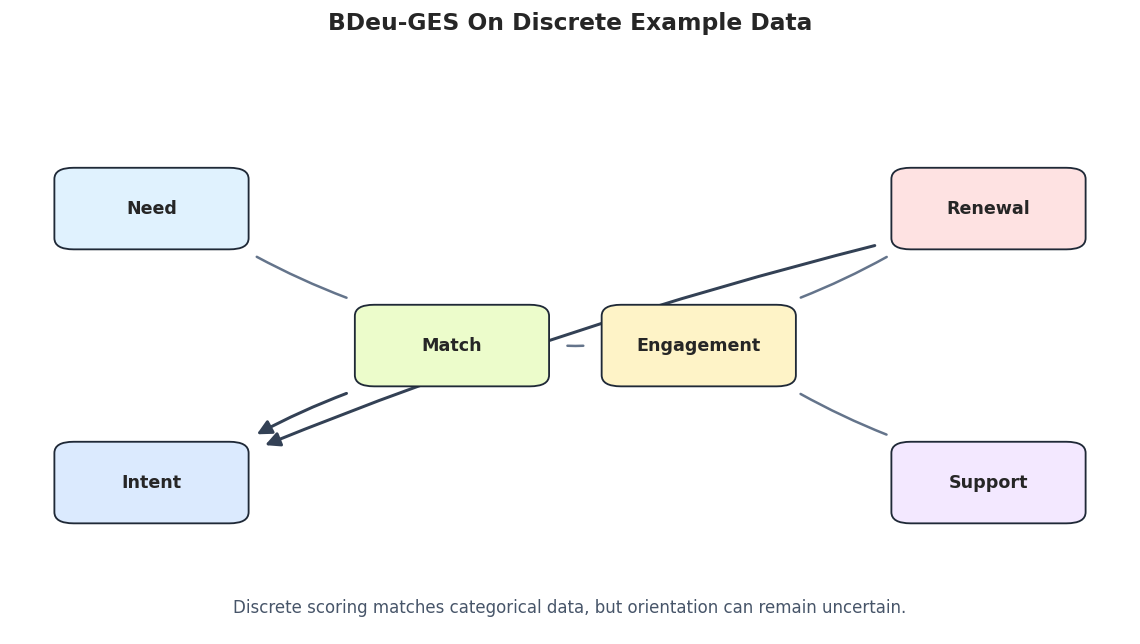

In [20]:
# Draw the BDeu-GES graph on discrete data.
bdeu_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_bdeu_ges_graph.png"
draw_box_graph(
    bdeu_edges,
    title="BDeu-GES On Discrete Example Data",
    path=bdeu_graph_path,
    note="Discrete scoring matches categorical data, but orientation can remain uncertain.",
)


The BDeu graph is a good reminder that matching score type to data type is necessary but not sufficient. A score can be appropriate and still leave several edges uncertain.




#### Score Function Runtime and Use Cases

The next table summarizes score functions you may encounter in causal-learn. The lesson runs the fast, stable choices by default and leaves the slower kernel/CV scores as optional experiments.


| score_function | data_type | main_assumption | run_by_default | approx_runtime_on_this_dataset | when_to_try |
| --- | --- | --- | --- | --- | --- |
| local_score_BIC | continuous | linear Gaussian local models | True | seconds | baseline score-based discovery for continuous data |
| local_score_BDeu | discrete | categorical Bayesian-network score with documented priors | True | seconds | discrete variables with a clear state space |
| local_score_CV_general | continuous | kernel regression with cross-validated likelihood | False | 5-15+ minutes | nonlinear relationships when longer runtime is acceptable |
| local_score_marginal_general | continuous | kernel marginal likelihood style score | False | 5-15+ minutes or more | nonlinear sensitivity checks on smaller samples first |


This guide is included because score choice is both statistical and computational. A slower nonlinear score should usually be tested on a smaller sample or reduced variable set before it becomes part of a default analysis pipeline.





## Reporting and Takeaways

### Combined Scenario Summary

This table gathers the main runs into one place: baseline BIC-GES, PC, selected penalty runs, sample-size runs, mechanism stress tests, and BDeu-GES. It becomes the compact summary for the lesson.


In [21]:
# Combine the most important metric tables into one scenario summary.
scenario_summary = pd.concat(
    [
        ges_metrics.assign(section="baseline_bic_ges"),
        pc_metrics.assign(section="constraint_based_comparison"),
        lambda_metrics.assign(section="bic_penalty_sensitivity"),
        sample_metrics.assign(section="sample_size_sensitivity"),
        regime_metrics.assign(section="mechanism_stress_test"),
        bdeu_metrics.assign(section="discrete_bdeu_example"),
    ],
    ignore_index=True,
    sort=False,
)
scenario_summary = scenario_summary[["section"] + [col for col in scenario_summary.columns if col != "section"]]
scenario_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_scenario_summary_metrics.csv", index=False)
display(scenario_summary)


,section,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies,lambda_value,sample_size,dataset
0,baseline_bic_ges,bic_ges_linear_gaussian,6,6,6,6,1.000000,1.000000,0,0,0,0,NaN,NaN,NaN
1,constraint_based_comparison,pc_fisherz_linear_gaussian,6,6,6,6,1.000000,1.000000,0,0,0,0,NaN,NaN,NaN
2,bic_penalty_sensitivity,bic_ges_lambda_0.25,6,6,6,6,1.000000,1.000000,0,0,0,0,0.25,NaN,NaN
3,bic_penalty_sensitivity,bic_ges_lambda_0.5,6,6,6,6,1.000000,1.000000,0,0,0,0,0.50,NaN,NaN
4,bic_penalty_sensitivity,bic_ges_lambda_1,7,4,6,1,0.250000,0.166667,2,3,0,1,1.00,NaN,NaN
5,bic_penalty_sensitivity,bic_ges_lambda_2,7,4,6,1,0.250000,0.166667,2,3,0,1,2.00,NaN,NaN
6,sample_size_sensitivity,bic_ges_n_100,7,2,6,2,1.000000,0.333333,0,4,0,1,NaN,100.0,NaN
7,sample_size_sensitivity,bic_ges_n_250,6,6,6,6,1.000000,1.000000,0,0,0,0,NaN,250.0,NaN
8,sample_size_sensitivity,bic_ges_n_500,6,6,6,6,1.000000,1.000000,0,0,0,0,NaN,500.0,NaN
9,sample_size_sensitivity,bic_ges_n_1000,6,6,6,6,1.000000,1.000000,0,0,0,0,NaN,1000.0,NaN


The scenario summary is the main audit table. It shows where score-based discovery works cleanly and where the result becomes sensitive to penalty, sample size, or model mismatch.


### GES Reporting Checklist

A score-based discovery report should document more than the final graph. The checklist below captures the key details that make a GES result easier to evaluate.


| topic | question_to_answer | reporting_note |
| --- | --- | --- |
| score choice | Which score was used, and why does it match the data type and mechanism assumptions? | BIC, BDeu, and kernel scores answer different modeling questions. |
| penalty or priors | What penalty coefficient or score prior was used? | Graph density can change when the complexity penalty changes. |
| search path | How many forward and backward updates occurred? | The final graph is easier to debug when the search path is visible. |
| sample-size sensitivity | Does the graph stabilize as sample size increases? | Small-sample score differences can be noisy. |
| model mismatch | What happens when the same score is run on data with different mechanisms? | A score can be fast and elegant but still wrong for nonlinear data. |
| claim strength | Which edges are stable candidate structure rather than confirmed causal directions? | GES returns a discovered graph under assumptions, not a final causal proof. |


The checklist turns the lesson into reusable practice. Score-based discovery is most useful when the score assumptions, tuning choices, and stability checks are all visible.


## Summary


At this point, the score-based discovery workflow covers BIC-GES, PC comparison, search history, penalty sensitivity, sample-size sensitivity, mechanism mismatch, discrete BDeu scoring, runtime guidance, and reporting outputs. The sequence next goes deeper into exact search and score functions on smaller graphs.
